# Total Assets vs. 12-Month Sales Analysis

Bloomberg Intelligence listed 50 companies to watch in 2018. Twelve of the companies are listed here with their total assets and 12-month sales.

| Company                  | Total Assets ($ Billions) ($x$) | 12-Month Sales ($ Billions) ($y$) |
| :----------------------- | :------------------------------ | :-------------------------------- |
| Eni SpA                  | 134.47                          | 68.13                             |
| Discovery Communications | 16.15                           | 6.59                              |
| Dong Energy              | 20.5                            | 9.16                              |
| AMD                      | 3.37                            | 4.62                              |
| Cabot Oil & Gas          | 5.22                            | 1.58                              |
| Engie                    | 166.84                          | 72.0                              |
| AMC Entertainment        | 9.81                            | 4.19                              |
| DSV                      | 6.14                            | 10.54                             |
| Alaska Air               | 10.7                            | 6.9                               |
| Boohoo.com               | 0.235                           | 0.545                             |
| Danone                   | 52.12                           | 25.11                             |
| Experian                 | 7.69                            | 4.34                              |

- **Independent variable ($x$):** Total Assets ($ Billions)
- **Dependent variable ($y$):** 12-Month Sales ($ Billions)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "Company": [
        "Eni SpA", "Discovery Communications", "Dong Energy", "AMD",
        "Cabot Oil & Gas", "Engie", "AMC Entertainment", "DSV",
        "Alaska Air", "Boohoo.com", "Danone", "Experian"
    ],
    "Assets": [134.47, 16.15, 20.5, 3.37, 5.22, 166.84, 9.81, 6.14, 10.7, 0.235, 52.12, 7.69],
    "Sales": [68.13, 6.59, 9.16, 4.62, 1.58, 72.0, 4.19, 10.54, 6.9, 0.545, 25.11, 4.34]
})
df

,Company,Assets,Sales
0,Eni SpA,134.470,68.130
1,Discovery Communications,16.150,6.590
2,Dong Energy,20.500,9.160
3,AMD,3.370,4.620
4,Cabot Oil & Gas,5.220,1.580
5,Engie,166.840,72.000
6,AMC Entertainment,9.810,4.190
7,DSV,6.140,10.540
8,Alaska Air,10.700,6.900
9,Boohoo.com,0.235,0.545


## a. Draw a scatter diagram.

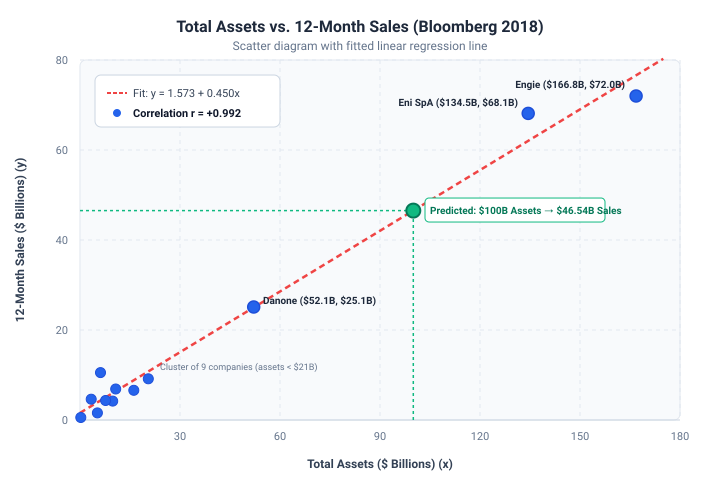

In [2]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df["Assets"], df["Sales"], color="#2563eb", s=70, zorder=3, edgecolors="#1d4ed8", linewidths=1.2)

# Annotate key companies
for _, row in df[df["Assets"] > 40].iterrows():
    ax.annotate(
        f"{row['Company']} (${row['Assets']}B, ${row['Sales']}B)",
        (row["Assets"], row["Sales"]),
        textcoords="offset points",
        xytext=(-15, 8),
        fontsize=9,
        weight="bold"
    )

# Regression line: y = 1.573 + 0.450x
m, b = np.polyfit(df["Assets"], df["Sales"], 1)
x_vals = np.linspace(0, 175, 100)
ax.plot(x_vals, m * x_vals + b, color="#ef4444", linestyle="--", linewidth=2, label=f"Fit: y = {b:.3f} + {m:.3f}x")

# Highlight prediction for $100B assets
pred_100 = b + m * 100
ax.scatter([100], [pred_100], color="#10b981", s=110, zorder=4, edgecolors="#047857", linewidths=2, label=f"Pred ($100B): ${pred_100:.2f}B")
ax.plot([100, 100], [0, pred_100], color="#10b981", linestyle=":", alpha=0.7)
ax.plot([0, 100], [pred_100, pred_100], color="#10b981", linestyle=":", alpha=0.7)

ax.set_title("Total Assets vs. 12-Month Sales (Bloomberg 2018)", fontsize=13, pad=12, fontweight="bold")
ax.set_xlabel("Total Assets ($ Billions)", fontsize=11)
ax.set_ylabel("12-Month Sales ($ Billions)", fontsize=11)
ax.set_xlim(0, 180)
ax.set_ylim(0, 80)
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## b. Compute the correlation coefficient.

### Step-by-Step Calculation Table

Sample size $n = 12$:
- Mean of $x$: $\bar{x} = \frac{\sum x}{n} = \frac{433.245}{12} = 36.10375$
- Mean of $y$: $\bar{y} = \frac{\sum y}{n} = \frac{213.705}{12} = 17.80875$

| Company | $x$ (Assets) | $y$ (Sales) | $x - \bar{x}$ | $(x - \bar{x})^2$ | $y - \bar{y}$ | $(y - \bar{y})^2$ | $(x - \bar{x})(y - \bar{y})$ |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| Eni SpA | 134.470 | 68.130 | 98.366 | 9675.922 | 50.321 | 2532.227 | 4949.914 |
| Discovery Comms | 16.150 | 6.590 | -19.954 | 398.152 | -11.219 | 125.860 | 223.859 |
| Dong Energy | 20.500 | 9.160 | -15.604 | 243.477 | -8.649 | 74.801 | 134.955 |
| AMD | 3.370 | 4.620 | -32.734 | 1071.498 | -13.189 | 173.943 | 431.716 |
| Cabot Oil & Gas | 5.220 | 1.580 | -30.884 | 953.806 | -16.229 | 263.372 | 501.214 |
| Engie | 166.840 | 72.000 | 130.736 | 17091.963 | 54.191 | 2936.691 | 7084.778 |
| AMC Entertainment | 9.810 | 4.190 | -26.294 | 691.362 | -13.619 | 185.470 | 358.087 |
| DSV | 6.140 | 10.540 | -29.964 | 897.826 | -7.269 | 52.835 | 217.799 |
| Alaska Air | 10.700 | 6.900 | -25.404 | 645.351 | -10.909 | 119.001 | 277.124 |
| Boohoo.com | 0.235 | 0.545 | -35.869 | 1286.567 | -17.264 | 298.037 | 619.231 |
| Danone | 52.120 | 25.110 | 16.016 | 256.520 | 7.301 | 53.308 | 116.939 |
| Experian | 7.690 | 4.340 | -28.414 | 807.341 | -13.469 | 181.408 | 382.695 |
| **Total ($\Sigma$)** | **433.245** | **213.705** | **0.000** | **34019.787** | **0.000** | **6996.955** | **15298.280** |

### Sum of Squares & Cross Products
- $SS_{xx} = \sum (x - \bar{x})^2 = 34,019.787$
- $SS_{yy} = \sum (y - \bar{y})^2 = 6,996.955$
- $SS_{xy} = \sum (x - \bar{x})(y - \bar{y}) = 15,298.280$

### Correlation Coefficient ($r$)
$$r = \frac{SS_{xy}}{\sqrt{SS_{xx} \cdot SS_{yy}}} = \frac{15298.280}{\sqrt{34019.787 \times 6996.955}} = \frac{15298.280}{\sqrt{238034912.45}} = \frac{15298.280}{15428.380} \approx \mathbf{0.9916} \approx \mathbf{0.992}$$

- There is an **extremely strong positive linear correlation** between total assets and 12-month sales.

In [3]:
r = df["Assets"].corr(df["Sales"])
print(f"Pearson correlation coefficient r = {r:.4f}")
print(f"Coefficient of determination r^2 = {r**2:.4f}")

Pearson correlation coefficient r = 0.9916
Coefficient of determination r^2 = 0.9832


## c. Determine the regression equation.

The linear regression equation is given by:
$$\hat{y} = b_0 + b_1 x$$

1. **Slope ($b_1$):**
   $$b_1 = \frac{SS_{xy}}{SS_{xx}} = \frac{15298.280}{34019.787} \approx \mathbf{0.4497} \quad (\approx 0.450)$$

2. **Y-Intercept ($b_0$):**
   $$b_0 = \bar{y} - b_1 \bar{x} = 17.80875 - (0.449688 \times 36.10375) = 17.80875 - 16.23541 = \mathbf{1.5733} \quad (\approx 1.573)$$

3. **Regression Equation:**
   $$\mathbf{\hat{y} = 1.573 + 0.450x} \quad \text{or} \quad \mathbf{\hat{y} = 1.5733 + 0.4497x}$$

*Interpretation:* For every additional $1 billion increase in total assets, 12-month sales increase by approximately $0.450 billion ($450 million).

In [4]:
b1, b0 = np.polyfit(df["Assets"], df["Sales"], 1)
print(f"Slope (b1) = {b1:.4f}")
print(f"Intercept (b0) = {b0:.4f}")
print(f"Regression equation: y_hat = {b0:.4f} + {b1:.4f} * x")

Slope (b1) = 0.4497
Intercept (b0) = 1.5733
Regression equation: y_hat = 1.5733 + 0.4497 * x


## d. For a company with $100 billion in assets, predict the 12-month sales.

Substitute $x = 100$ into the regression equation:

$$\hat{y} = 1.5733 + 0.4497(100)$$
$$\hat{y} = 1.5733 + 44.9688 = \mathbf{46.5421} \text{ billion dollars}$$

**Predicted 12-month sales:** approximately **$46.54 billion**.

In [5]:
x_pred = 100
y_pred = b0 + b1 * x_pred
print(f"Predicted 12-month sales for $100B in assets: ${y_pred:.2f} billion")

Predicted 12-month sales for $100B in assets: $46.54 billion
